# CSIC 2010 Web Application Attacks EDA + Training

This Dataset from kaggle :

https://www.kaggle.com/datasets/ispangler/csic-2010-web-application-attacks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import math
import pathlib
import re

In [3]:
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
dataset_path = "../csic_database.csv"  # run from ML/ ; project root holds the CSV

In [7]:
csic_df = pd.read_csv(dataset_path)

In [8]:
n_features= csic_df.shape[1]
n_samples =  csic_df.shape[0]

In [9]:
print("Number of samples:", n_samples)
print("Number of features:", n_features)

Number of samples: 61065
Number of features: 17


In [10]:
csic_df.shape  # Confirm

(61065, 17)

In [11]:
csic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61065 entries, 0 to 61064
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       61065 non-null  object
 1   Method           61065 non-null  object
 2   User-Agent       61065 non-null  object
 3   Pragma           61065 non-null  object
 4   Cache-Control    61065 non-null  object
 5   Accept           60668 non-null  object
 6   Accept-encoding  61065 non-null  object
 7   Accept-charset   61065 non-null  object
 8   language         61065 non-null  object
 9   host             61065 non-null  object
 10  cookie           61065 non-null  object
 11  content-type     17977 non-null  object
 12  connection       61065 non-null  object
 13  lenght           17977 non-null  object
 14  content          17977 non-null  object
 15  classification   61065 non-null  int64 
 16  URL              61065 non-null  object
dtypes: int64(1), object(16)
memory 

In [12]:
csic_df.dtypes

Unnamed: 0         object
Method             object
User-Agent         object
Pragma             object
Cache-Control      object
Accept             object
Accept-encoding    object
Accept-charset     object
language           object
host               object
cookie             object
content-type       object
connection         object
lenght             object
content            object
classification      int64
URL                object
dtype: object

In [13]:
csic_df.head()

,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.j...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&...,0,http://localhost:8080/tienda1/publico/anadir.j...
3,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=8FA18BA82C5336D03D3A8AFA3E68CBB0,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/autentic...
4,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7104E6C68A6BCF1423DAE990CE49FEE2,application/x-www-form-urlencoded,Connection: close,Content-Length: 63,modo=entrar&login=choong&pwd=d1se3ci%F3n&remem...,0,http://localhost:8080/tienda1/publico/autentic...


In [14]:
csic_df.columns

Index(['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control',
       'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host',
       'cookie', 'content-type', 'connection', 'lenght', 'content',
       'classification', 'URL'],
      dtype='object')

In [15]:
# get the number of missing data points per feature
print(f'number of features: {n_features}')
missing_values_count = csic_df.isnull().sum()
missing_values_count

number of features: 17


Unnamed: 0             0
Method                 0
User-Agent             0
Pragma                 0
Cache-Control          0
Accept               397
Accept-encoding        0
Accept-charset         0
language               0
host                   0
cookie                 0
content-type       43088
connection             0
lenght             43088
content            43088
classification         0
URL                    0
dtype: int64

In [16]:
# compute percentage of data that is missing (set to Null)
total_cells = np.prod(csic_df.shape)
total_missing = missing_values_count.sum()
percent_missing = (total_missing/total_cells) * 100
print('percentage missing:',(f'{percent_missing:.2f}') ,'%')

percentage missing: 12.49 %


In [17]:
#compute the number of unique values in each feature
for feature in csic_df.columns:
    if feature in csic_df.columns:
        unique_count = csic_df[feature].nunique()
        print(f"Number of unique values for {feature}: {unique_count}")
    else:
        print(f"Column '{feature}' does not exist in the DataFrame.")

Number of unique values for Unnamed: 0: 2
Number of unique values for Method: 3
Number of unique values for User-Agent: 1
Number of unique values for Pragma: 1
Number of unique values for Cache-Control: 1
Number of unique values for Accept: 1
Number of unique values for Accept-encoding: 1
Number of unique values for Accept-charset: 1
Number of unique values for language: 1
Number of unique values for host: 2
Number of unique values for cookie: 61065
Number of unique values for content-type: 1
Number of unique values for connection: 2
Number of unique values for lenght: 382
Number of unique values for content: 12091
Number of unique values for classification: 2
Number of unique values for URL: 13498


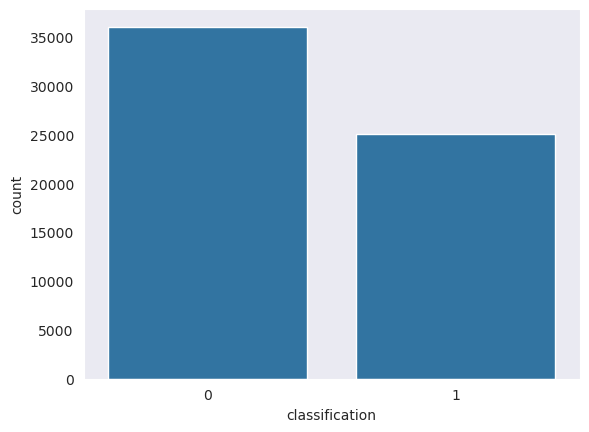

In [18]:
# Visualization fo  targets
sns.set_style("dark")
sns.countplot(x=csic_df['classification'])
plt.show()

In [19]:
# Check URL Format
csic_df.URL[0]

'http://localhost:8080/tienda1/index.jsp HTTP/1.1'

In [20]:
# Check Features
feature_names=[ 'Unnamed: 0','Method', 'User-Agent', 'Pragma', 'Cache-Control',
       'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host',
       'cookie', 'content-type', 'connection', 'lenght', 'content','classification',
        'URL']

In [21]:
# Asign X features vectors
X = csic_df[feature_names]

In [22]:
# Remove Unnecessary feautues
for feature in csic_df.columns :

  if feature in csic_df.columns:

    solo = csic_df[feature].nunique()
    print(f"Number of solo values for { feature} :: {solo}")

  else :

    print(f"Cols  {feature} not exists in df")

Number of solo values for Unnamed: 0 :: 2
Number of solo values for Method :: 3
Number of solo values for User-Agent :: 1
Number of solo values for Pragma :: 1
Number of solo values for Cache-Control :: 1
Number of solo values for Accept :: 1
Number of solo values for Accept-encoding :: 1
Number of solo values for Accept-charset :: 1
Number of solo values for language :: 1
Number of solo values for host :: 2
Number of solo values for cookie :: 61065
Number of solo values for content-type :: 1
Number of solo values for connection :: 2
Number of solo values for lenght :: 382
Number of solo values for content :: 12091
Number of solo values for classification :: 2
Number of solo values for URL :: 13498


In [23]:
# Removing not discriminatory Features and edit cols names
X = X.rename(columns={'Unnamed: 0': 'Class'})
X = X.rename(columns={'lenght': 'content_length'})

In [24]:
feature_names=[ 'Class','Method','host','cookie','Accept', 'content_length', 'content','classification','URL']

In [25]:
y = csic_df['classification']

In [26]:
print(y.shape)

(61065,)


In [27]:
# Get list of categorical variables
s = (X.dtypes == 'object')
object_cols = list(s[s].index)

In [28]:
print("Categorical variables:")
print(object_cols)

Categorical variables:
['Class', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie', 'content-type', 'connection', 'content_length', 'content', 'URL']


In [29]:
#replace NaN values with 0
#removing the 'Content-Lenght' string and keeping only the numerical value
X['content_length'] = X['content_length'].astype(str)
X['content_length'] = X['content_length'].str.extract(r'(\d+)')
X['content_length'] = pd.to_numeric(X['content_length'], errors='coerce').fillna(0)
print(X.content_length)

0          0.0
1          0.0
2         68.0
3          0.0
4         63.0
         ...  
61060      0.0
61061    255.0
61062      0.0
61063      0.0
61064      0.0
Name: content_length, Length: 61065, dtype: float64


In [30]:
filtered_length = X.loc[X['Method'] == 'GET', 'content_length']
print(filtered_length)

0        0.0
1        0.0
3        0.0
5        0.0
7        0.0
        ... 
61058    0.0
61060    0.0
61062    0.0
61063    0.0
61064    0.0
Name: content_length, Length: 43088, dtype: float64


## Pre-Process URLs

In [31]:
# Extract the top 10 most common strings
url_counts = X['URL'].value_counts()
most_common_urls = url_counts.head(10)

In [32]:
print("Most common URLs:")
for i, (url, count) in enumerate(most_common_urls.items(), 1):
    print(f"{i}. URL: {url} - Count: {count}")

Most common URLs:
1. URL: http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1 - Count: 2441
2. URL: http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1 - Count: 2422
3. URL: http://localhost:8080/tienda1/publico/registro.jsp HTTP/1.1 - Count: 2417
4. URL: http://localhost:8080/tienda1/miembros/editar.jsp HTTP/1.1 - Count: 2412
5. URL: http://localhost:8080/tienda1/publico/pagar.jsp HTTP/1.1 - Count: 2379
6. URL: http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1 - Count: 2003
7. URL: http://localhost:8080/tienda1/publico/vaciar.jsp HTTP/1.1 - Count: 1965
8. URL: http://localhost:8080/tienda1/publico/entrar.jsp HTTP/1.1 - Count: 1938
9. URL: http://localhost:8080/tienda1/miembros/imagenes/zarauz.jpg HTTP/1.1 - Count: 1000
10. URL: http://localhost:8080/tienda1/imagenes/cmenbul.gif HTTP/1.1 - Count: 1000


URL Utils Functions

In [33]:
from urllib.parse import urlparse

In [34]:
def count_dot(url):
    count_dot = url.count('.')
    return count_dot

def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

In [35]:
def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)
    if match:
        return 1
    else:
        return 0

In [36]:
def count_http(url):
    return url.count('http')

def count_per(url):
    return url.count('%')

def count_ques(url):
    return url.count('?')

def count_hyphen(url):
    return url.count('-')

def count_equal(url):
    return url.count('=')

def url_length(url):
    return len(str(url))

def hostname_length(url):
    return len(urlparse(url).netloc)

In [37]:
score_map = {
        'error': 30,
        'errorMsg': 30,
        'id': 10,
        'errorID': 30,
        'SELECT': 50,
        'FROM': 50,
        'WHERE': 50,
        'DELETE': 50,
        'USERS': 50,
        'DROP': 50,
        'CREATE': 50,
        'INJECTED': 50,
        'TABLE': 50,
        'alert': 30,
        'javascript': 20,
        'cookie': 25,
        '--': 30,
        '.exe': 30,
        '.php': 20,
        '.js': 10,
        'admin': 10,
        'administrator': 10,
        '\'': 30,
        'password': 15,
        'login': 15,
        'incorrect': 20,
        'pwd': 15,
        'tamper': 25,
        'vaciar': 20,
        'carrito': 25,
        'wait': 30,
        'delay': 35,
        'set': 20,
        'steal': 35,
        'hacker': 35,
        'proxy': 35,
        'location': 30,
        'document.cookie': 40,
        'document': 20,
        'set-cookie': 40,
        'create': 40,
        'cmd': 40,
        'dir': 30,
        'shell': 40,
        'reverse': 30,
        'bin': 20,
        'cookiesteal': 40,
        'LIKE': 30,
        'UNION': 35,
        'include': 30,
        'file': 20,
        'tmp': 25,
        'ssh': 40,
        'exec': 30,
        'cat': 25,
        'etc': 30,
        'fetch': 25,
        'eval': 30,
        'wait': 30,
        'malware': 45,
        'ransomware': 45,
        'phishing': 45,
        'exploit': 45,
        'virus': 45,
        'trojan': 45,
        'backdoor': 45,
        'spyware': 45,
        'rootkit': 45,
        'credential': 30,
        'inject': 30,
        'script': 25,
        'iframe': 25,
        'src=': 25,
        'onerror': 30,
        'prompt': 20,
        'confirm': 20,
        'eval': 25,
        'expression': 30,
        'function\(': 20,
        'xmlhttprequest': 30,
        'xhr': 20,
        'window.': 20,
        'document.': 20,
        'cookie': 25,
        'click': 15,
        'mouseover': 15,
        'onload': 20,
        'onunload': 20,
    }


In [38]:
import re

In [39]:
def suspicious_words(url):

    global score_map
    matches = re.findall(r'(?i)' + '|'.join(score_map.keys()), url)

    total_score = sum(score_map.get(match.lower(), 0) for match in matches)

    return total_score

In [40]:
# Characters Counts
def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits

def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters += 1
    return letters

def count_special_characters(url):
    special_characters = re.sub(r'[a-zA-Z0-9\s]', '', url)
    count = len(special_characters)
    return count

In [41]:
# Number of Parameters in URL
def number_of_parameters(url):
    params = urlparse(url).query
    return 0 if params == '' else len(params.split('&'))

# Number of Fragments in URL
def number_of_fragments(url):
    frags = urlparse(url).fragment
    return len(frags.split('#')) - 1 if frags == '' else 0

# URL is Encoded
def is_encoded(url):
    return int('%' in url.lower())


In [42]:
def unusual_character_ratio(url):
    total_characters = len(url)
    unusual_characters = re.sub(r'[a-zA-Z0-9\s\-._]', '', url)
    unusual_count = len(unusual_characters)
    ratio = unusual_count / total_characters if total_characters > 0 else 0
    return ratio

In [43]:
X['count_dot_url'] = X['URL'].apply(count_dot)
X['count_dir_url'] = X['URL'].apply(no_of_dir)
X['count_embed_domain_url'] = X['URL'].apply(no_of_embed)
X['short_url'] = X['URL'].apply(shortening_service)
X['count-http'] = X['URL'].apply(count_http)
X['count%_url'] = X['URL'].apply(count_per)
X['count?_url'] = X['URL'].apply(count_ques)
X['count-_url'] = X['URL'].apply(count_hyphen)
X['count=_url'] = X['URL'].apply(count_equal)
X['hostname_length_url'] = X['URL'].apply(hostname_length)
X['sus_url'] = X['URL'].apply(suspicious_words)
X['count-digits_url'] = X['URL'].apply(digit_count)
X['count-letters_url'] = X['URL'].apply(letter_count)
X['url_length'] = X['URL'].apply(url_length)
X['number_of_parameters_url'] = X['URL'].apply(number_of_parameters)
X['number_of_fragments_url'] = X['URL'].apply(number_of_fragments)
X['is_encoded_url'] = X['URL'].apply(is_encoded)
X['special_count_url'] = X['URL'].apply(count_special_characters)
X['unusual_character_ratio_url'] = X['URL'].apply(unusual_character_ratio)

In [44]:
chosen_features = ['count_dot_url', 'count_dir_url', 'count_embed_domain_url', 'count-http',
                'count%_url', 'count?_url', 'count-_url', 'count=_url', 'url_length', 'hostname_length_url',
                'sus_url', 'count-digits_url', 'count-letters_url', 'number_of_parameters_url',
                'number_of_fragments_url', 'is_encoded_url','special_count_url','unusual_character_ratio_url']

In [45]:
# Create a new DataFrame within this chosen features
set = X[chosen_features]

In [46]:
X.head(5)

,Class,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,...,hostname_length_url,sus_url,count-digits_url,count-letters_url,url_length,number_of_parameters_url,number_of_fragments_url,is_encoded_url,special_count_url,unusual_character_ratio_url
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,14,10,7,31,48,0,0,0,9,0.145833
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,14,115,15,86,126,5,0,1,24,0.174603
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,14,40,7,39,57,0,0,0,10,0.140351
3,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,14,40,11,92,125,5,0,1,21,0.152000
4,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,14,10,7,43,61,0,0,0,10,0.131148


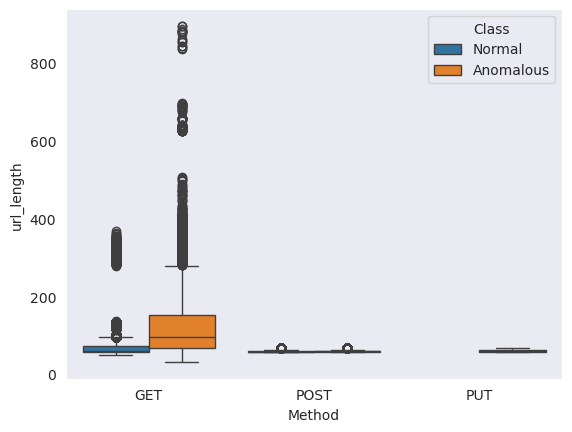

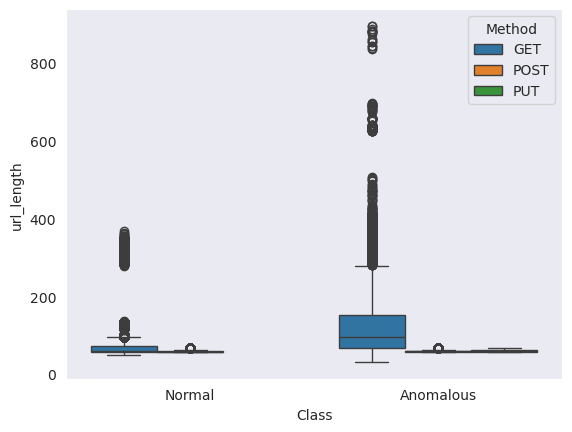

In [47]:
#Plot Dataset based on the features"Method" and "Content_Length" for each class

sns.boxplot(data=X, x='Method', y='url_length', hue='Class')
plt.show()
sns.boxplot(data=X, x='Class', y='url_length', hue='Method')
plt.show()

## Remove Cookies as Feautes
Thet are not usefull for model training

In [48]:
unique_count = X['cookie'].nunique()
print(f"Count of unique values in 'cookie': {unique_count}")

Count of unique values in 'cookie': 61065


## Encoding Categorical Featueres

In [49]:
X['Accept'] = X['Accept'].astype(str)
X['Accept'] = X['Accept'].str.extract(r'(\d+)')
X['Accept'] = pd.to_numeric(X['Accept'], errors='coerce').fillna(1)

In [50]:
lb_make = LabelEncoder()
X["Method_enc"] = lb_make.fit_transform(X["Method"])
X["host_enc"] =lb_make.fit_transform(X["host"])
X["Accept_enc"] =lb_make.fit_transform(X["Accept"])

In [51]:
solo_count_met = X["Method_enc"].nunique()
solo_count_host = X["host_enc"].nunique()
solo_count_acc = X["Accept_enc"].nunique()

## Validate

In [52]:
print(f"Number of solo values for 'Method_enc': {solo_count_met}")
print(f"Number of solo values for 'host_enc': {solo_count_host}")
print(f"Number of solo values for 'Accept_enc': {solo_count_acc}")

Number of solo values for 'Method_enc': 3
Number of solo values for 'host_enc': 2
Number of solo values for 'Accept_enc': 2


In [53]:
X.head()

,Class,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,...,count-letters_url,url_length,number_of_parameters_url,number_of_fragments_url,is_encoded_url,special_count_url,unusual_character_ratio_url,Method_enc,host_enc,Accept_enc
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,0.0,"x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,31,48,0,0,0,9,0.145833,0,0,0
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,0.0,"x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,86,126,5,0,1,24,0.174603,0,0,0
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,0.0,"x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,39,57,0,0,0,10,0.140351,1,0,0
3,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,0.0,"x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,92,125,5,0,1,21,0.152000,0,0,0
4,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,0.0,"x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,...,43,61,0,0,0,10,0.131148,1,0,0


In [54]:
def apply_to_content(content,function):

    if pd.isna(content):
        return 0

    elif isinstance(content, str):
        return function(content)

In [55]:

X['count_dot_content'] = X['content'].apply(apply_to_content, function=count_dot)
X['count_dir_content'] = X['content'].apply(apply_to_content, function=no_of_dir)
X['count_embed_domain_content'] = X['content'].apply(apply_to_content, function=no_of_embed)
X['count%_content'] = X['content'].apply(apply_to_content, function=count_per)
X['count?_content'] = X['content'].apply(apply_to_content, function=count_ques)
X['count-_content'] = X['content'].apply(apply_to_content, function=count_hyphen)
X['count=_content'] = X['content'].apply(apply_to_content, function=count_equal)
X['content_length'] = X['content'].apply(apply_to_content, function=url_length)
X['sus_content'] = X['content'].apply(apply_to_content, function=suspicious_words)
X['count_digits_content'] = X['content'].apply(apply_to_content, function=digit_count)
X['count_letters_content'] = X['content'].apply(apply_to_content, function=letter_count)
X['special_count_content'] = X['content'].apply(apply_to_content, function=count_special_characters)
X['is_encoded_content'] = X['content'].apply(apply_to_content, function=is_encoded)

In [56]:
# Select the features and class variable for training
new_content_features = ['count_dot_content', 'count_dir_content', 'count_embed_domain_content', 'count%_content', 'count?_content',
                        'count-_content', 'count=_content', 'sus_content', 'count_digits_content',
                        'count_letters_content', 'content_length', 'is_encoded_content', 'special_count_content']

In [57]:
# Create a DataFrame with the selected features
selected_features_df = X[new_content_features]

for feature_name in selected_features_df.columns:
    if feature_name in X.columns:
        solo_count = selected_features_df[feature_name].nunique()
        print(f"Number of unique values for {feature_name}: {solo_count}")
    else:
        print(f"Column '{feature_name}' does not exist in the DataFrame.")

Number of unique values for count_dot_content: 8
Number of unique values for count_dir_content: 1
Number of unique values for count_embed_domain_content: 1
Number of unique values for count%_content: 34
Number of unique values for count?_content: 1
Number of unique values for count-_content: 8
Number of unique values for count=_content: 5
Number of unique values for sus_content: 57
Number of unique values for count_digits_content: 111
Number of unique values for count_letters_content: 230
Number of unique values for content_length: 383
Number of unique values for is_encoded_content: 2
Number of unique values for special_count_content: 87


In [58]:
print(X.columns)

Index(['Class', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept',
       'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie',
       'content-type', 'connection', 'content_length', 'content',
       'classification', 'URL', 'count_dot_url', 'count_dir_url',
       'count_embed_domain_url', 'short_url', 'count-http', 'count%_url',
       'count?_url', 'count-_url', 'count=_url', 'hostname_length_url',
       'sus_url', 'count-digits_url', 'count-letters_url', 'url_length',
       'number_of_parameters_url', 'number_of_fragments_url', 'is_encoded_url',
       'special_count_url', 'unusual_character_ratio_url', 'Method_enc',
       'host_enc', 'Accept_enc', 'count_dot_content', 'count_dir_content',
       'count_embed_domain_content', 'count%_content', 'count?_content',
       'count-_content', 'count=_content', 'sus_content',
       'count_digits_content', 'count_letters_content',
       'special_count_content', 'is_encoded_content'],
      dtype='object')


In [59]:
# Check that new_content_features and X are defined correctly
print("new_content_features:", new_content_features)
print("X columns:", X.columns)

new_content_features: ['count_dot_content', 'count_dir_content', 'count_embed_domain_content', 'count%_content', 'count?_content', 'count-_content', 'count=_content', 'sus_content', 'count_digits_content', 'count_letters_content', 'content_length', 'is_encoded_content', 'special_count_content']
X columns: Index(['Class', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept',
       'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie',
       'content-type', 'connection', 'content_length', 'content',
       'classification', 'URL', 'count_dot_url', 'count_dir_url',
       'count_embed_domain_url', 'short_url', 'count-http', 'count%_url',
       'count?_url', 'count-_url', 'count=_url', 'hostname_length_url',
       'sus_url', 'count-digits_url', 'count-letters_url', 'url_length',
       'number_of_parameters_url', 'number_of_fragments_url', 'is_encoded_url',
       'special_count_url', 'unusual_character_ratio_url', 'Method_enc',
       'host_enc', 'Accept_enc', 'coun

In [60]:
## Labels
labels = chosen_features + ['Method_enc', 'host_enc', 'Accept_enc'] + new_content_features

In [61]:
y=X['classification']  # target binary classification : 0 , 1

## Splitter

In [62]:
X = X[labels]
X_tr, X_test,  y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## BuildUp Classiffier Model

In [63]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_tr, y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [106]:
rf_pred = random_forest_model.predict(X_test)

In [108]:
print('MAE', mean_absolute_error(y_test, rf_pred))
print("Accuracy", accuracy_score(y_test, rf_pred))
print("Precision", precision_score(y_test, rf_pred, average='weighted', labels=np.unique(rf_pred)))
print("Recall", recall_score(y_test, rf_pred, average='weighted', labels=np.unique(rf_pred)))
print("F1", f1_score(y_test, rf_pred, average='weighted', labels=np.unique(rf_pred)))
print("ROC AUC", roc_auc_score(y_test, rf_pred, average='weighted', labels=np.unique(rf_pred)))
error_rt = (rf_pred != y_test).mean()
print("Test error: {:.1%}".format(error_rt))

MAE 0.07729468599033816
Accuracy 0.9227053140096618
Precision 0.9226521216059502
Recall 0.9227053140096618
F1 0.9226737404007442
ROC AUC 0.9199867585960023
Test error: 7.7%


In [109]:
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [111]:
for k in range( np.unique(y_test).size ):
  print("mean of class " + str( k ) + "\n"  ,  X_test[y_test == k ].mean(axis=0) )

mean of class 0
 count_dot_url                   2.073727
count_dir_url                   3.822468
count_embed_domain_url          0.000000
count-http                      1.000000
count%_url                      0.274902
count?_url                      0.229715
count-_url                      0.026441
count=_url                      1.194740
url_length                     79.570229
hostname_length_url            14.000000
sus_url                        21.329743
count-digits_url                9.864997
count-letters_url              55.393816
number_of_parameters_url        1.194740
number_of_fragments_url         0.000000
is_encoded_url                  0.093173
special_count_url              13.311416
unusual_character_ratio_url     0.140298
Method_enc                      0.227756
host_enc                        0.000000
Accept_enc                      0.000000
count_dot_content               0.068691
count_dir_content               0.000000
count_embed_domain_content      0.000000

In [112]:
classifier_report =  classification_report(y_test, rf_pred)
print(classifier_report)

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7148
           1       0.91      0.90      0.91      5065

    accuracy                           0.92     12213
   macro avg       0.92      0.92      0.92     12213
weighted avg       0.92      0.92      0.92     12213



In [115]:
# Confusion Matrix
label = ['Normal', 'Anomalous']
cm = confusion_matrix(y_test, rf_pred)
cm = pd.DataFrame(cm, index=['0', '1'], columns=['0', '1'])

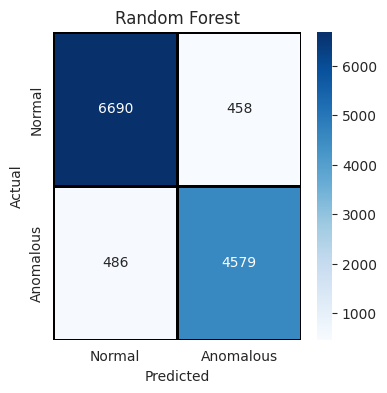

In [117]:
# Show Confusion matrix
plt.figure(figsize=(4,4))
sns.heatmap(cm, cmap="Blues", linecolor='black', linewidth=1, annot=True, fmt='', xticklabels=label, yticklabels=label)
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [118]:
import joblib

In [ ]:
# baseline model (hand-crafted features); the improved pipeline is saved below
joblib.dump(random_forest_model, '../models/webattack/csic_rf_baseline.joblib')

## Improved model: TF-IDF char n-grams + Logistic Regression
Decode the URL/body (URL-encoding hides the payloads), drop duplicate requests (~58% of rows repeat) so the test set is not leaked, then TF-IDF over characters feeds a linear classifier. A Random Forest on the same features reached 93% accuracy at 13 MB (pruning it to <1 MB dropped it to ~85%); Logistic Regression reaches ~97.5% at ~330 KB. Saved as one sklearn `Pipeline`.

In [64]:
import os, json
from urllib.parse import unquote_plus
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline



In [65]:
def build_text(url, content):
    return unquote_plus(unquote_plus(f"{url} {content}")).lower()


In [66]:
df2 = pd.read_csv(dataset_path)
df2['text'] = [build_text(u.rsplit(' HTTP/', 1)[0], c if isinstance(c, str) else '')
               for u, c in zip(df2.URL, df2.content)]


In [67]:
df2 = df2.drop_duplicates(subset='text').reset_index(drop=True)
Xt, yt = df2['text'], df2['classification']
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.2, random_state=42, stratify=yt)

In [69]:
from sklearn.linear_model import LogisticRegression
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2, 4), 
                              max_features=20000, sublinear_tf=True)),
    ('clf', LogisticRegression(C=100, max_iter=2000)),]).fit(Xt_tr, yt_tr)


In [70]:
pipe_pred = pipe.predict(Xt_te)
print(classification_report(yt_te, pipe_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9565    0.9803    0.9683      1929
           1     0.9875    0.9721    0.9797      3085

    accuracy                         0.9753      5014
   macro avg     0.9720    0.9762    0.9740      5014
weighted avg     0.9756    0.9753    0.9753      5014



In [72]:
import  joblib

In [73]:
os.makedirs('../models/webattack', exist_ok=True)
joblib.dump(pipe, '../models/webattack/webattack_lr.joblib', compress=3)

['../models/webattack/webattack_lr.joblib']

In [74]:

json.dump(dict(model='webattack_lr', classes={'0': 'Normal', '1': 'Anomalous'},
               input="str '<url> <body>' (no ' HTTP/1.x'); apply build_text first",
               sklearn_version=sklearn.__version__,
               metrics=dict(accuracy=accuracy_score(yt_te, pipe_pred), precision=precision_score(yt_te, pipe_pred),
                            recall=recall_score(yt_te, pipe_pred), f1=f1_score(yt_te, pipe_pred))),
          open('../models/webattack/metadata.json', 'w'), indent=2)